# Project 3 – Do periods of rapid GDP growth coincide with increases in the Democracy Index?

This project explores the relationship between economic development and democratization. Specifically, I ask Do periods of rapid GDP per capita growth coincide with increases in the Democracy Index?

The underlying hypothesis is that economic development is associated with democratization: when a country’s economy grows quickly, we might expect political institutions and democratic rights to improve as well.

## Prompt

Dataset(s) to be used:

- GDP per capita (PPP, international $), by country and year  
  - Source: (Our World in Data – GDP per capita)[https://ourworldindata.org/grapher/gdp-per-capita-worldbank]
  - File used in this notebook: `GDP.csv`

- Democracy Index by country and year  
  - Source: (V-Dem)[https://v-dem.net/data/the-v-dem-dataset/]
  - File used in this notebook: `democracy_index.csv`

Analysis question:

- Do periods of rapid GDP per capita growth coincide with increases in the Democracy Index?

Columns that will (likely) be used:

From GDP dataset (`GDP.csv`):

- country (Entity)
- year (Year)
- gdp_pc_ppp
- region

From democracy dataset (`democracy_index.csv`):

- country
- year
- democracy_index

Columns to be used to merge/join them:

- GDP: country + year
- Democracy Index: country + year

Hypothesis:

- Countries experiencing rapid GDP per capita growth will be more likely to show increases in their Democracy Index in the same year or shortly thereafter. In other words, economic development is associated with democratization.

In the rest of this notebook, I will:

1. Load and inspect the GDP and Democracy Index datasets.  
2. Compute year-on-year GDP per capita growth and year-on-year change in the Democracy Index.  
3. Define what counts as a “rapid GDP growth” year and a “democratization” year using data-driven thresholds.  
4. Visualize the relationship between GDP growth and changes in democracy.  
5. Look at example countries over time to see how economic and political changes move together.  
6. Summarize what the results suggest about my original hypothesis.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Plotting style
sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


# Setup and data loading

First, I import the libraries I need and load the GDP dataset and the Democracy Index dataset into pandas DataFrames.

The GDP file `GDP.csv` contains GDP per capita (PPP, constant 2021 international dollars) by country and year, from Our World in Data.

The democracy file `democracy_index.csv` contains a numeric democracy score by country and year. The exact columns and scale can vary by source, so I will standardize column names after I inspect it.

In [46]:
# Load GDP and democracy datasets
gdp = pd.read_csv("/GDP.csv")
dem = pd.read_csv("/liberal-democracy-index.csv")

print("GDP columns:")
print(gdp.columns.tolist())
print()
print("Democracy columns:")
print(dem.columns.tolist())

gdp.head(), dem.head()


GDP columns:
['Entity', 'Code', 'Year', 'GDP per capita, PPP (constant 2021 international $)', 'World regions according to OWID']

Democracy columns:
['Entity', 'Code', 'Year', 'Liberal democracy index (central estimate)', 'World regions according to OWID']


(        Entity Code  Year  \
 0  Afghanistan  AFG  2000   
 1  Afghanistan  AFG  2001   
 2  Afghanistan  AFG  2002   
 3  Afghanistan  AFG  2003   
 4  Afghanistan  AFG  2004   
 
    GDP per capita, PPP (constant 2021 international $)  \
 0                                          1617.8264     
 1                                          1454.1108     
 2                                          1774.3087     
 3                                          1815.9282     
 4                                          1776.9182     
 
   World regions according to OWID  
 0                             NaN  
 1                             NaN  
 2                             NaN  
 3                             NaN  
 4                             NaN  ,
         Entity Code  Year  Liberal democracy index (central estimate)  \
 0  Afghanistan  AFG  1789                                       0.029   
 1  Afghanistan  AFG  1790                                       0.029   
 2  Afghanistan  

# Cleaning and Preparing the Data

Before analyzing anything, I computed:

Year-on-year GDP per capita growth

Year-on-year change in democracy

Then I merged the datasets by country and year, after which I filtered missing values. After merging, that column of region was mostly N/A. Since region wasn’t needed for my core research question, I ignored it — but I note it here as part of the analysis process.

In [47]:
# ---- Clean GDP dataset ----

# Try to detect GDP per capita column automatically
gdp_cols = gdp.columns.tolist()
gdp_pc_col = None
for c in gdp_cols:
    if "GDP per capita" in c:
        gdp_pc_col = c
        break

if gdp_pc_col is None:
    raise ValueError("Could not find a GDP per capita column in GDP.csv. Check gdp.columns and set gdp_pc_col manually.")

gdp_rename_map = {
    "Entity": "country",
    "Year": "year",
    gdp_pc_col: "gdp_pc_ppp"
}

if "World regions according to OWID" in gdp.columns:
    gdp_rename_map["World regions according to OWID"] = "region"

gdp = gdp.rename(columns=gdp_rename_map)

keep_cols = ["country", "year", "gdp_pc_ppp"]
if "region" in gdp.columns:
    keep_cols.append("region")

gdp = gdp[keep_cols].copy()
gdp = gdp.dropna(subset=["gdp_pc_ppp"])
gdp = gdp.sort_values(["country", "year"]).reset_index(drop=True)

gdp.head()


,country,year,gdp_pc_ppp,region
0,Afghanistan,2000,1617.8264,NaN
1,Afghanistan,2001,1454.1108,NaN
2,Afghanistan,2002,1774.3087,NaN
3,Afghanistan,2003,1815.9282,NaN
4,Afghanistan,2004,1776.9182,NaN


In [48]:
dem.columns.tolist()

# Adjust these if your file uses slightly different names
dem = dem.rename(columns={
    "Entity": "country",
    "Year": "year",
    "Liberal democracy index (central estimate)": "democracy_index",
    "World regions according to OWID": "region"
})

dem = dem[["country", "year", "democracy_index"]].copy()
dem = dem.dropna(subset=["democracy_index"])
dem = dem.sort_values(["country", "year"]).reset_index(drop=True)

dem.head()



,country,year,democracy_index
0,Afghanistan,1789,0.029
1,Afghanistan,1790,0.029
2,Afghanistan,1791,0.029
3,Afghanistan,1792,0.029
4,Afghanistan,1793,0.029


In [49]:
# ---- Create growth/change variables ----

# GDP per capita growth (%)
gdp["gdp_growth_pc"] = gdp.groupby("country")["gdp_pc_ppp"].pct_change() * 100

# Change in democracy index (year-on-year)
dem["delta_democracy"] = dem.groupby("country")["democracy_index"].diff()

gdp.head(), dem.head()


(       country  year  gdp_pc_ppp region  gdp_growth_pc
 0  Afghanistan  2000   1617.8264    NaN            NaN
 1  Afghanistan  2001   1454.1108    NaN     -10.119479
 2  Afghanistan  2002   1774.3087    NaN      22.020186
 3  Afghanistan  2003   1815.9282    NaN       2.345674
 4  Afghanistan  2004   1776.9182    NaN      -2.148213,
        country  year  democracy_index  delta_democracy
 0  Afghanistan  1789            0.029              NaN
 1  Afghanistan  1790            0.029              0.0
 2  Afghanistan  1791            0.029              0.0
 3  Afghanistan  1792            0.029              0.0
 4  Afghanistan  1793            0.029              0.0)

In [50]:
# ---- Merge into a single analysis dataframe ----

df = pd.merge(
    gdp,
    dem,
    on=["country", "year"],
    how="inner"
)

df = df.dropna(subset=["gdp_growth_pc", "delta_democracy"]).reset_index(drop=True)

print(df["region"])
print(df["region"].value_counts(dropna=False))
df = df.drop(columns=["region"])

df.head()


0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
         ...  
5651       NaN
5652       NaN
5653       NaN
5654    Africa
5655       NaN
Name: region, Length: 5656, dtype: object
region
NaN              5488
Africa             52
Asia               44
Europe             41
North America      14
South America      11
Oceania             6
Name: count, dtype: int64


,country,year,gdp_pc_ppp,gdp_growth_pc,democracy_index,delta_democracy
0,Afghanistan,2001,1454.1108,-10.119479,0.029,0.007
1,Afghanistan,2002,1774.3087,22.020186,0.084,0.055
2,Afghanistan,2003,1815.9282,2.345674,0.086,0.002
3,Afghanistan,2004,1776.9182,-2.148213,0.091,0.005
4,Afghanistan,2005,1908.1147,7.383373,0.113,0.022


# Next step

Up to this point, we looked at scatterplots and density plots, which help us see whether a general relationship exists between GDP growth and changes in democracy. But because both variables are noisy and centered around zero, it’s hard to tell whether there is any systematic pattern during the most extreme (and potentially most meaningful) years.

To get a clearer picture, we classify years into two categories:

1. “Rapid GDP growth” years

We use the 75th percentile of GDP per capita growth as a data-driven cutoff, so we let the dataset tell us what counts as unusually high growth.

Only the top 25% of growth years are labeled “rapid”. This allows us to test whether unusually strong economic performance corresponds to unusually large improvements in democracy.

2. “Big democratization” years

We do the same for democracy: Compute the 75th percentile of year-to-year democracy changes. Label years above this threshold as “big democratization” years. Since democracy usually changes only slightly, this helps isolate the rare moments when institutions actually shift.

In [51]:
# ---- Define "rapid GDP growth" and "big democratization" years ----

gdp_growth_threshold = df["gdp_growth_pc"].quantile(0.75)
dem_change_threshold = df["delta_democracy"].quantile(0.75)

print("GDP growth threshold (75th percentile):", round(gdp_growth_threshold, 2), "%")
print("Democracy change threshold (75th percentile):", round(dem_change_threshold, 3))

df["rapid_gdp_growth"] = df["gdp_growth_pc"] >= gdp_growth_threshold
df["big_democratization"] = df["delta_democracy"] >= dem_change_threshold

crosstab = pd.crosstab(df["rapid_gdp_growth"], df["big_democratization"], normalize="all")
crosstab


GDP growth threshold (75th percentile): 4.39 %
Democracy change threshold (75th percentile): 0.004


big_democratization,False,True
rapid_gdp_growth,,
False,0.540311,0.209689
True,0.187058,0.062942


# First Look at the Data: Scatterplot

I began with a straightforward scatterplot of:

GDP per capita growth (%)
vs.
Change in the Liberal Democracy Index

The result looked like this:

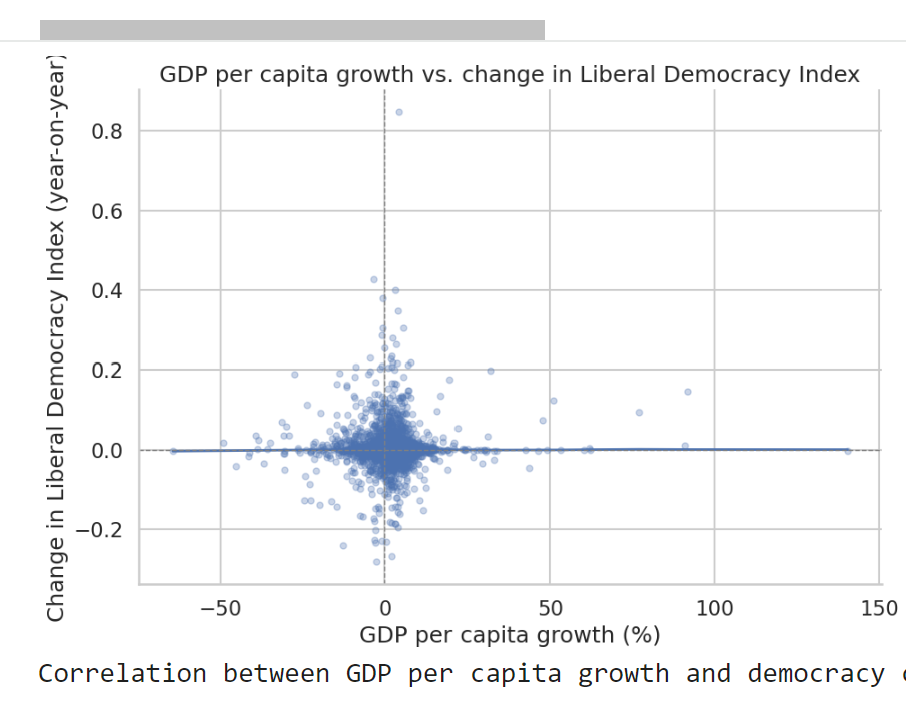

My first reaction was that there is no relationship here at all.

And the correlation coefficient confirmed this: 0.016

In other words: almost no linear association.

This is already an interesting finding. But before concluding, I wanted to dig deeper.

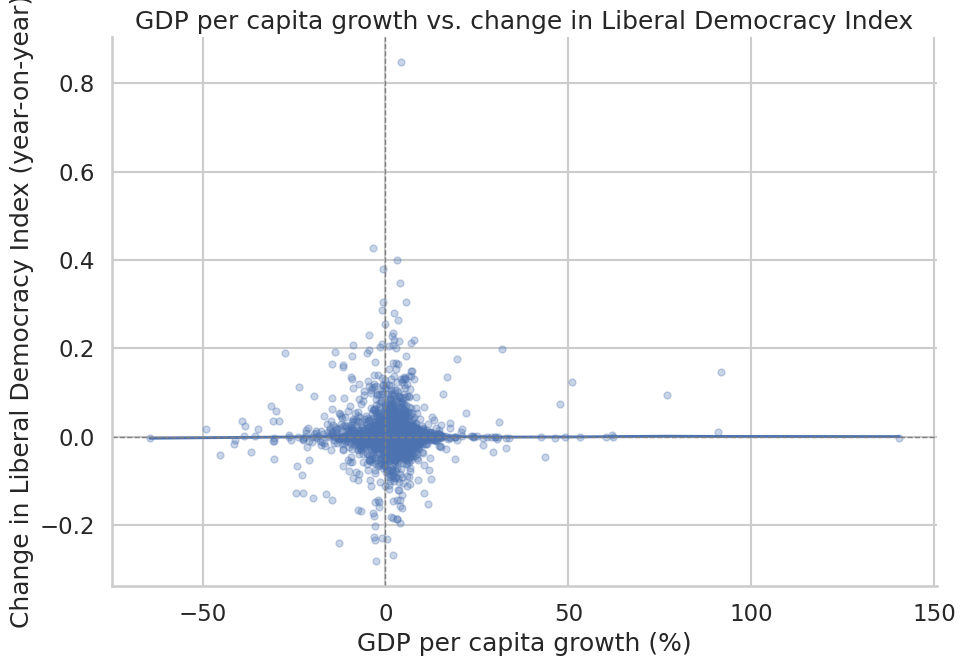

Correlation between GDP per capita growth and democracy change: 0.016


In [52]:
# ---- Visualization 1: scatter with smooth trend line ----

plt.figure(figsize=(10, 7))

sns.regplot(
    data=df,
    x="gdp_growth_pc",
    y="delta_democracy",
    lowess=True,
    scatter_kws={"alpha": 0.3, "s": 25},
    line_kws={"linewidth": 2}
)

plt.axvline(0, color="grey", linestyle="--", linewidth=1)
plt.axhline(0, color="grey", linestyle="--", linewidth=1)

plt.xlabel("GDP per capita growth (%)")
plt.ylabel("Change in Liberal Democracy Index (year-on-year)")
plt.title("GDP per capita growth vs. change in Liberal Democracy Index")
plt.tight_layout()
plt.show()

corr = df["gdp_growth_pc"].corr(df["delta_democracy"])
print(f"Correlation between GDP per capita growth and democracy change: {corr:.3f}")


# Improving the Visualization

GDP growth has some extreme outliers (for example, small economies experiencing ±100% swings). Democracies also rarely change dramatically from one year to the next — most changes are between –0.05 and +0.05.

To see the meaningful trends more clearly, I filtered out extreme values and plotted a joint density plot:

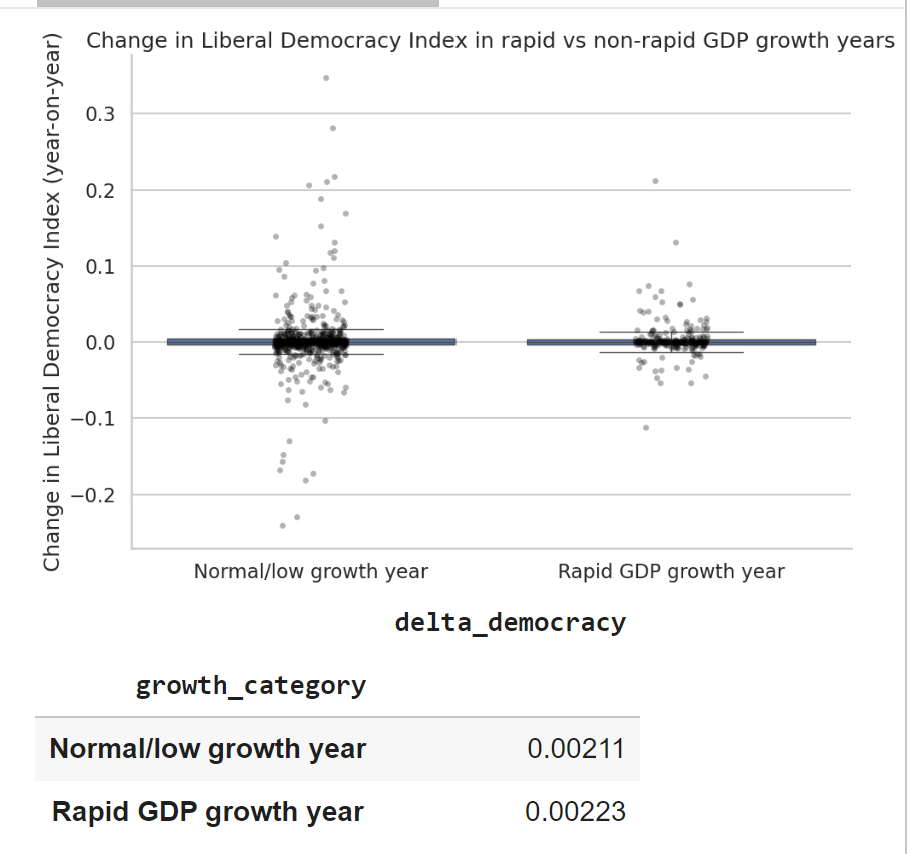

This smoothed visualization reinforced the same conclusion:
Most democracy changes are tiny, and they appear unrelated to GDP growth.

Still, this might simply mean that democratization is slow, and one-year changes are the wrong time horizon.

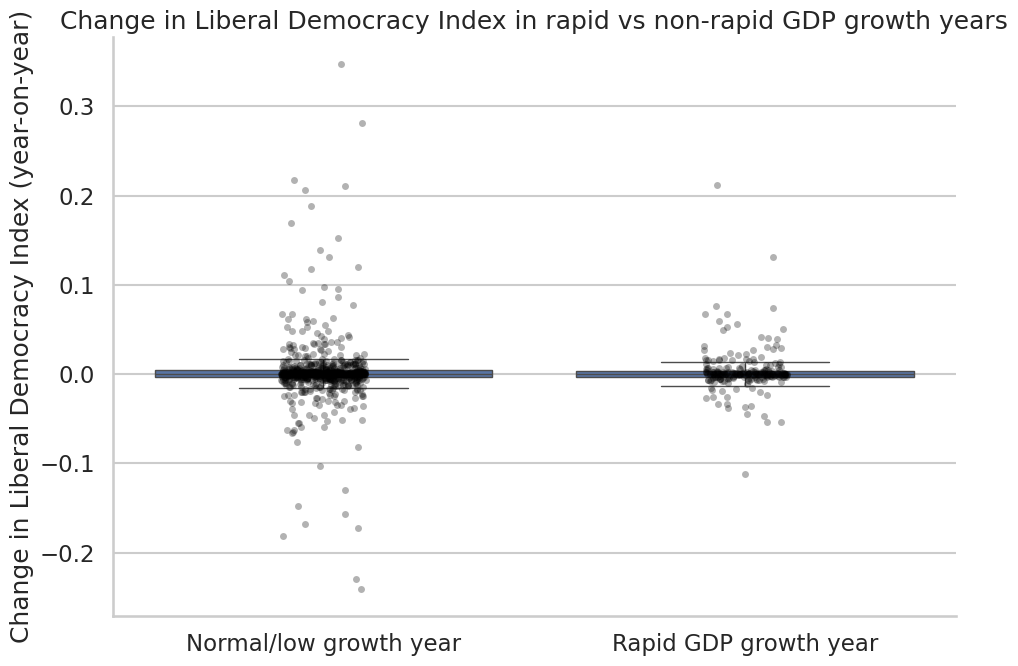

,delta_democracy
growth_category,
Normal/low growth year,0.00211
Rapid GDP growth year,0.00223


In [53]:
# ---- Visualization 2: boxplot comparing rapid vs non-rapid growth years ----

df["growth_category"] = np.where(df["rapid_gdp_growth"], "Rapid GDP growth year", "Normal/low growth year")

plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df,
    x="growth_category",
    y="delta_democracy",
    showfliers=False
)

sns.stripplot(
    data=df.sample(min(len(df), 1000), random_state=42),
    x="growth_category",
    y="delta_democracy",
    color="black",
    alpha=0.3
)

plt.xlabel("")
plt.ylabel("Change in Liberal Democracy Index (year-on-year)")
plt.title("Change in Liberal Democracy Index in rapid vs non-rapid GDP growth years")
plt.tight_layout()
plt.show()

df.groupby("growth_category")["delta_democracy"].mean()


#Looking at Country Examples Over Time

To better understand the dynamics, I selected a few countries and plotted both their:

Democracy Index trends

GDP per capita growth trends

for Brazil, India, Israel, Sweden, and Turkey.

Democracy over time, and for GDP growth over time:

What I noticed:

Sharp democracy declines (Brazil ~2015, Turkey ~2016, India ~2017–2023) do not correspond to GDP shocks.

Periods of strong GDP growth (India ~2000s, Israel ~mid 2000s) do not correspond to democratization leaps.

Sweden shows stable democracy and varied GDP growth — again, no relationship.

This suggests that political changes reflect institutional and political forces, not annual economic cycles.

In [54]:
year_to_plot = 2018

# Filter to that year
df_year = df[df["year"] == year_to_plot].copy()

print(f"Number of countries in {year_to_plot}:", len(df_year))

# ---- Choropleth 1: GDP per capita (PPP) ----
fig_gdp = px.choropleth(
    df_year,
    locations="country",
    locationmode="country names",
    color="gdp_pc_ppp",
    hover_name="country",
    color_continuous_scale="Viridis",
    title=f"GDP per capita (PPP) in {year_to_plot}",
)

fig_gdp.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    coloraxis_colorbar=dict(title="GDP per capita (PPP)")
)

fig_gdp.show()

# ---- Choropleth 2: Liberal Democracy Index ----
fig_dem = px.choropleth(
    df_year,
    locations="country",
    locationmode="country names",
    color="democracy_index",
    hover_name="country",
    color_continuous_scale="Blues",
    title=f"Liberal Democracy Index in {year_to_plot}",
)

fig_dem.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    coloraxis_colorbar=dict(title="Liberal Democracy Index")
)

fig_dem.show()

Number of countries in 2018: 169


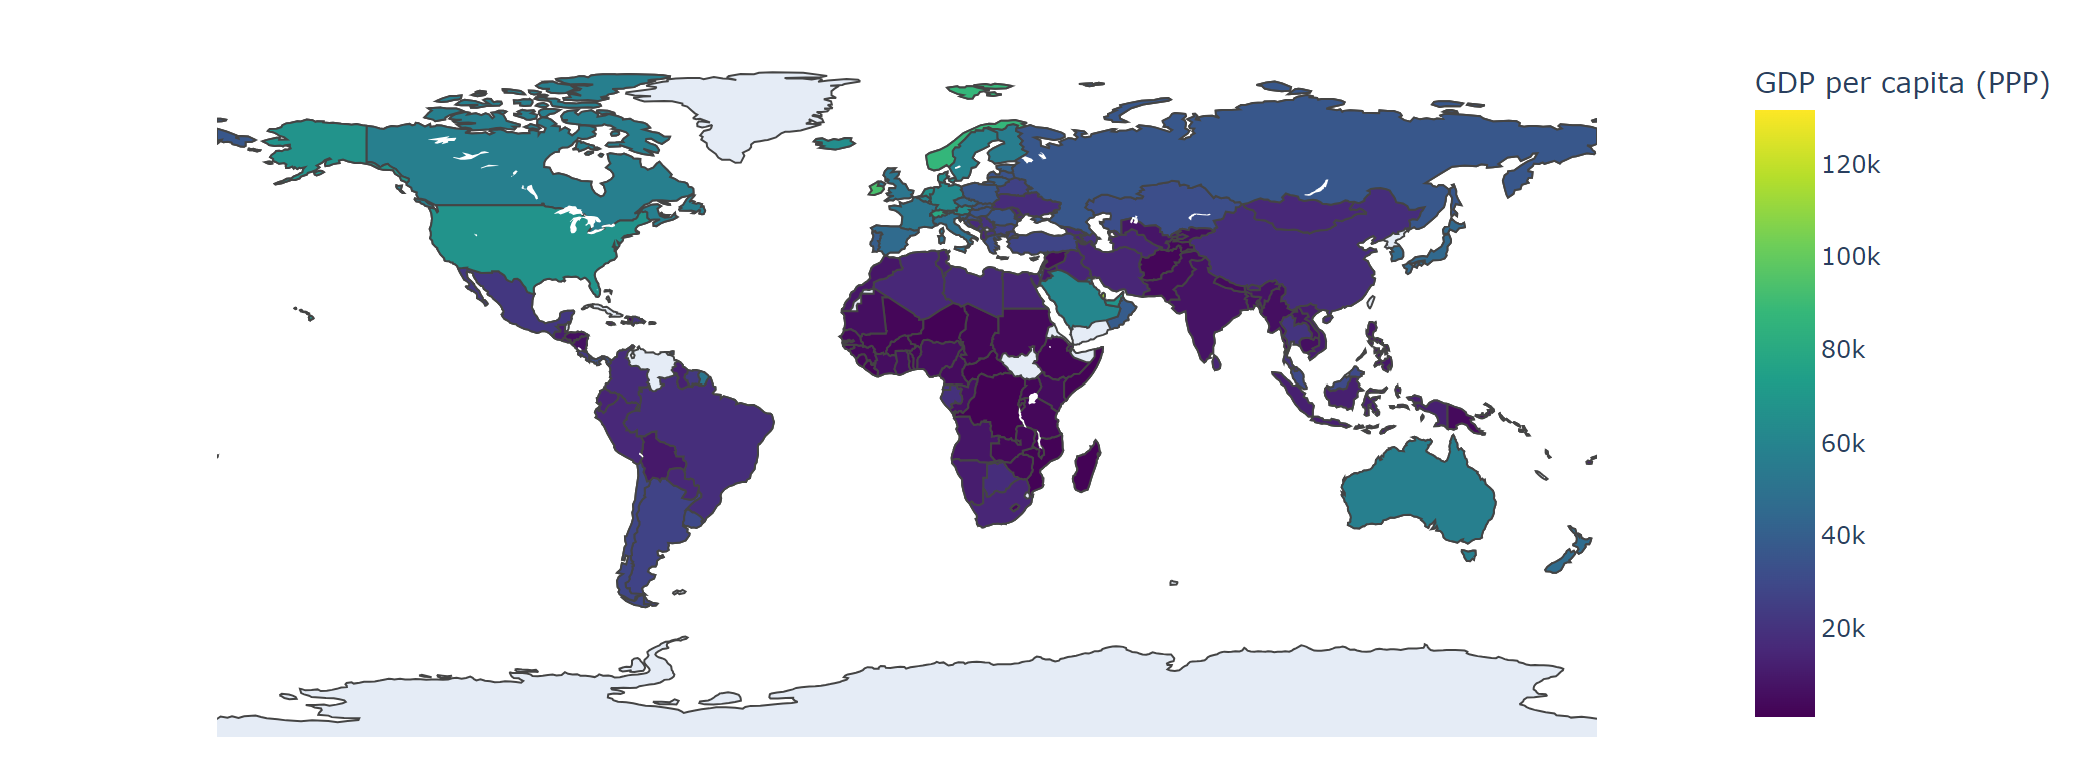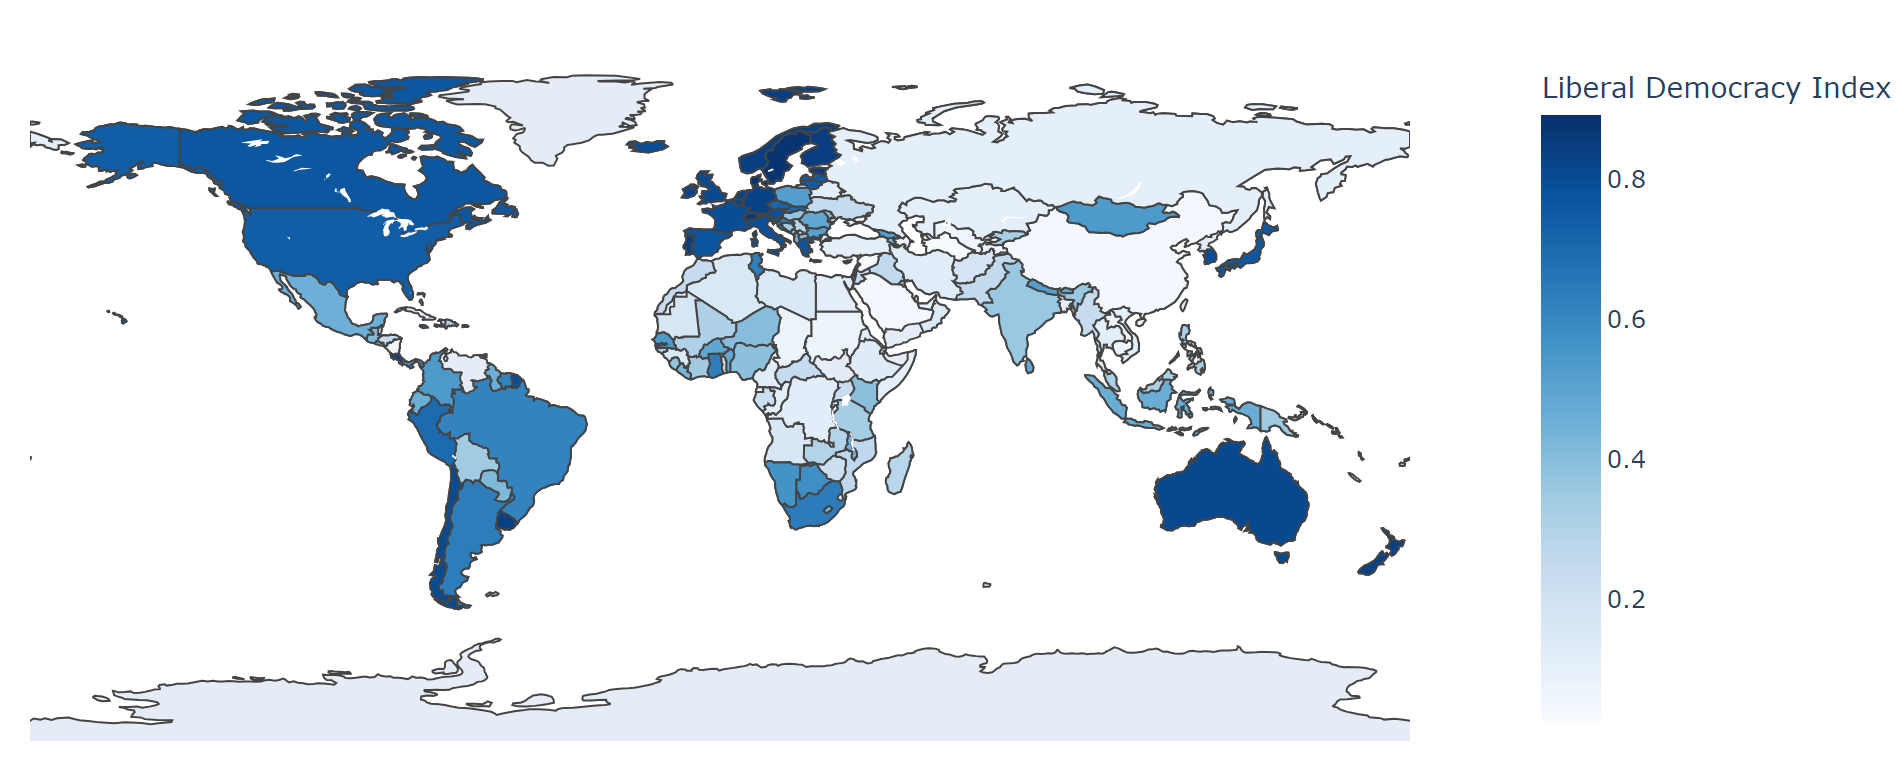

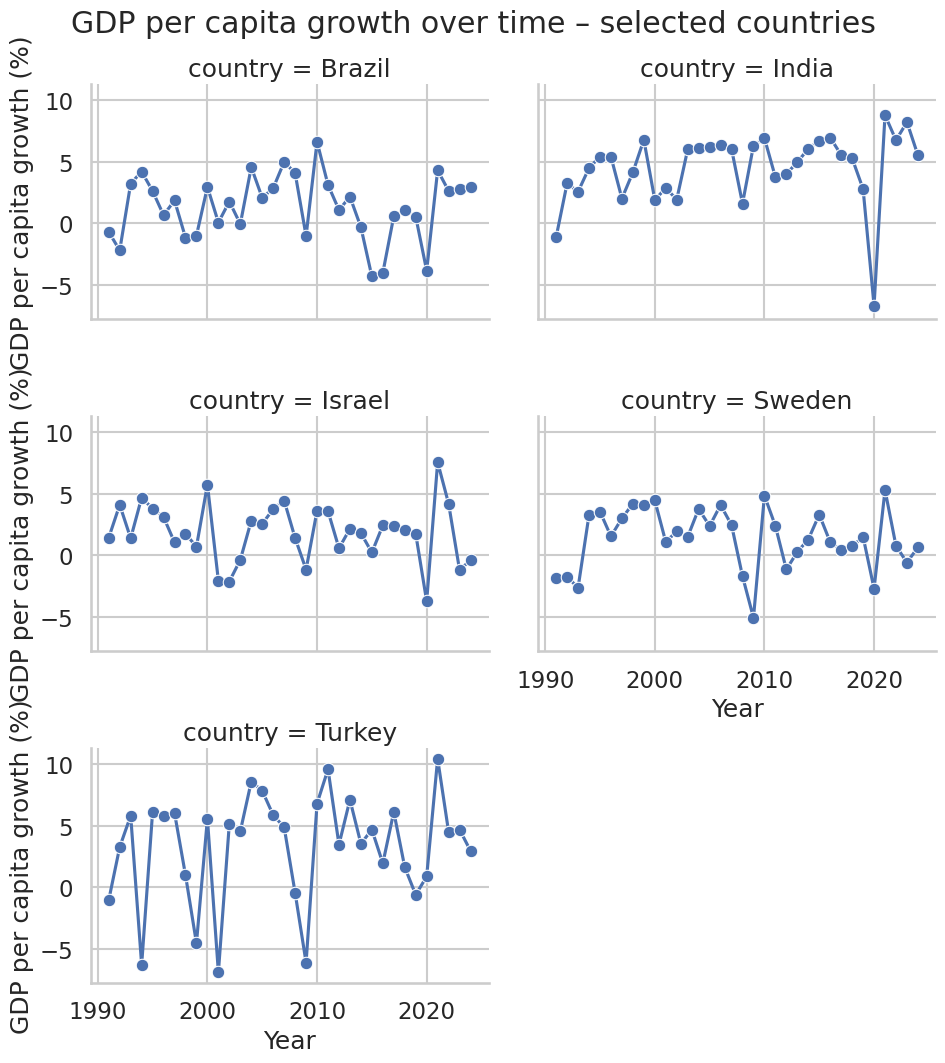

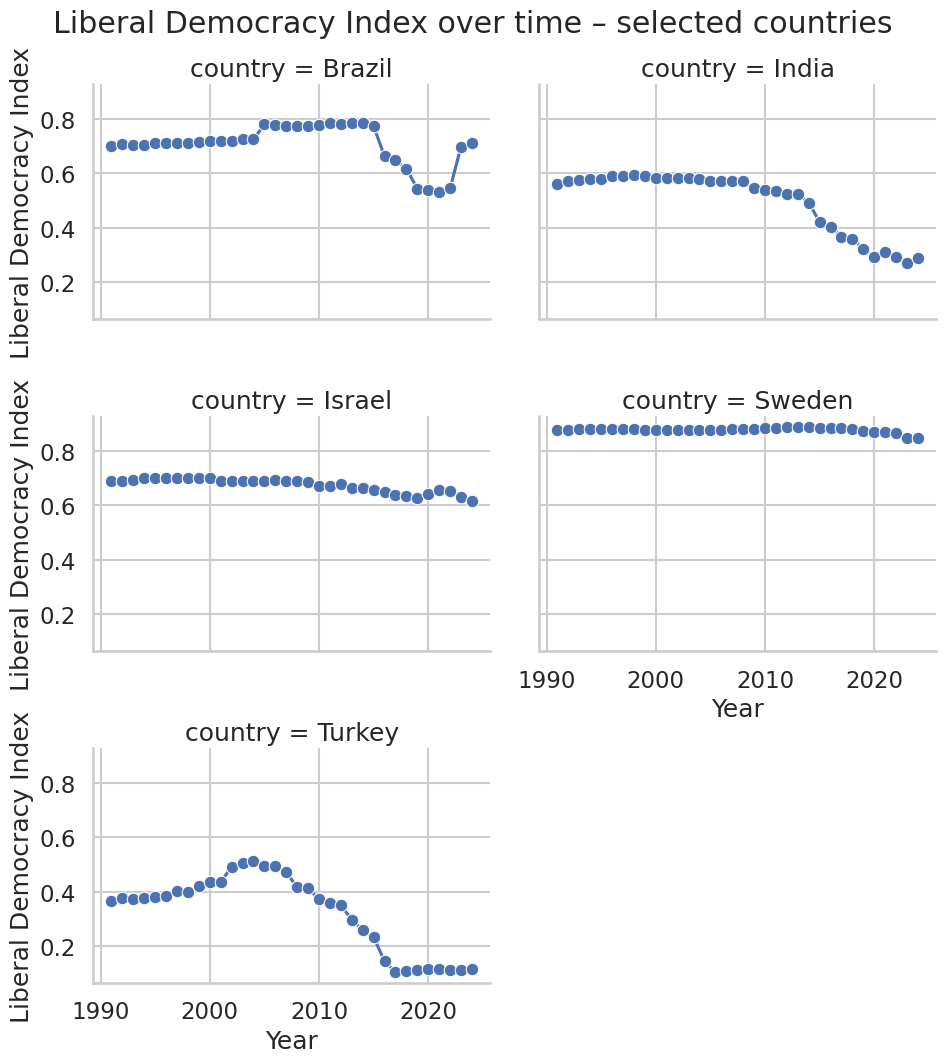

In [55]:
# ---- Visualization 3: country time series examples ----
# Change these country names to ones that actually exist in your data
example_countries = ["India", "Brazil", "Turkey", "Sweden", "Israel"]

df_examples = df[df["country"].isin(example_countries)].copy()

# GDP growth over time
g = sns.relplot(
    data=df_examples,
    x="year",
    y="gdp_growth_pc",
    col="country",
    kind="line",
    col_wrap=2,
    height=3.5,
    aspect=1.4,
    marker="o"
)

g.set_axis_labels("Year", "GDP per capita growth (%)")
g.fig.suptitle("GDP per capita growth over time – selected countries", y=1.02)
plt.show()

# Liberal Democracy Index over time
g2 = sns.relplot(
    data=df_examples,
    x="year",
    y="democracy_index",
    col="country",
    kind="line",
    col_wrap=2,
    height=3.5,
    aspect=1.4,
    marker="o"
)

g2.set_axis_labels("Year", "Liberal Democracy Index")
g2.fig.suptitle("Liberal Democracy Index over time – selected countries", y=1.02)
plt.show()


# Joint Density Plot

This plot shows the joint density of our two variables: GDP per capita growth (x-axis), Change in the Liberal Democracy Index (y-axis)

Instead of individual points, the shading represents where most observations cluster.

When I generated this visualization, I expected to see at least some pattern — maybe higher democracy changes occurring during periods of strong GDP growth. But the result is telling:

1. Almost all observations cluster tightly around zero democracy change

The democracy index barely moves from year to year. In most countries, institutions don’t shift quickly — they’re stable, path-dependent, or only change after major political shocks.
This is why the entire distribution is squeezed around 0.00 on the y-axis.

2. GDP growth varies, but democracy does not

Countries experience a wide range of GDP outcomes (from large contractions to rapid expansions), yet the democracy index remains nearly flat in those same years.
This suggests that short-term economic performance and political regime change operate on different time scales.

3. No visible relationship exists between the two variables

If economic growth caused democratization, we would expect to see upward sloping areas, more density in the upper-right (high growth + democratization), or more density in the lower-left (recession + autocratization). Instead, the density blob is nearly symmetrical around the origin, showing no directional association.

4. Extreme GDP growth outliers do not produce meaningful democracy shifts

Even in years where GDP per capita changed by +20%, –20%, or more, democracy scores stayed essentially the same.
This strongly contradicts the idea that democratization responds immediately to economic gains.

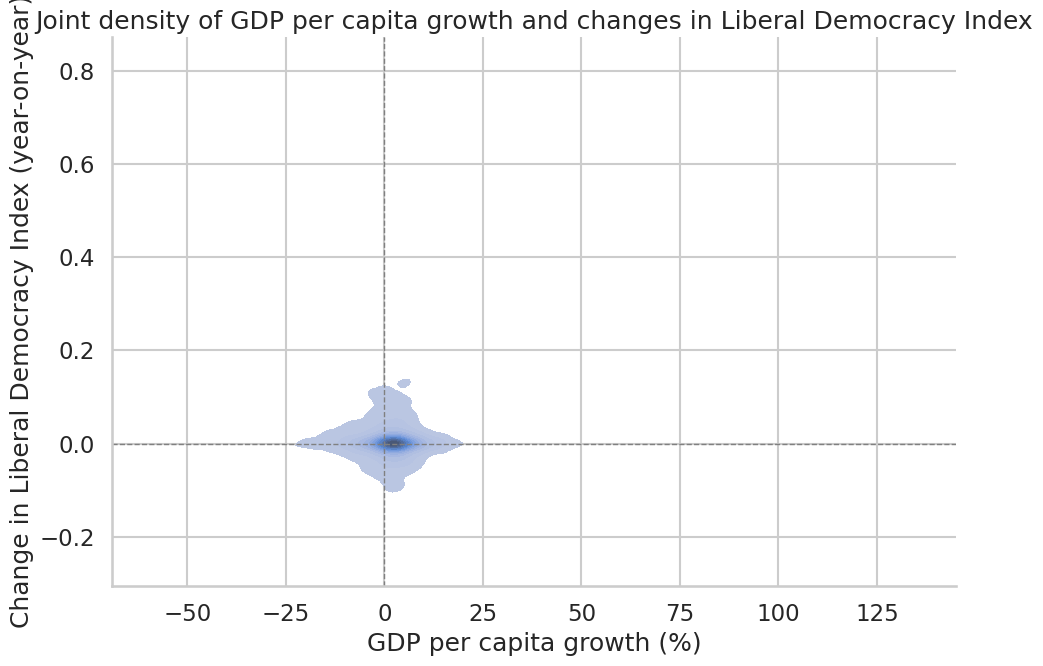

In [56]:
# Visualization 4: joint density (KDE) ----

plt.figure(figsize=(10, 7))

sns.kdeplot(
    data=df,
    x="gdp_growth_pc",
    y="delta_democracy",
    fill=True,
    thresh=0.05,
    levels=15
)

plt.axvline(0, color="grey", linestyle="--", linewidth=1)
plt.axhline(0, color="grey", linestyle="--", linewidth=1)

plt.xlabel("GDP per capita growth (%)")
plt.ylabel("Change in Liberal Democracy Index (year-on-year)")
plt.title("Joint density of GDP per capita growth and changes in Liberal Democracy Index")
plt.tight_layout()
plt.show()


# Final Interpretation

Across all methods — scatterplots, density estimation, country case examples, categorical comparisons — the results are consistent:

1. Year-to-year economic growth does not predict democratization.
The correlation is effectively zero.

2. Rapid GDP growth years look almost identical to other years in terms of democracy change.
No positive effect.

3. Major democratization events do not align with rapid economic growth.
Only about 6% of such events occur in rapid-growth years.

4. Democracy changes slowly, while GDP growth fluctuates yearly.
These are fundamentally different processes.

My original hypothesis was:

“Countries experiencing rapid GDP per capita growth will be more likely to show increases in their Democracy Index.”

Based on the data: This hypothesis is not supported.

There’s no evidence, at least over one-year windows, that economic booms produce democratic improvements.

That suggests that democratization may operate on a longer time scale (10–20 years). Or it depends on institutional, regional, or historical factors, not short-term GDP changes.

But within the scope of year-to-year changes, the answer is clear: Economic growth and democracy do not move together in the short term.